# Homework 2 — Generative Models for Inverse Problems

Come da indicazione, qui **non si addestra nulla**: si caricano i pesi
ufficiali della lezione (`VAE.pth` e `DDPMDenoiser.pth`) e si usano per risolvere il
problema inverso `y = K x + e` con tre prior generativi: **VAE latent prior**, **DPS** e **DiffPIR**.

## 0. Setup — GPU, Drive, dati e pesi

In [17]:
import torch
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

CUDA: False | no GPU


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# IPPy (operatore di blur). Se hai la versione di Virtuale sul Drive puoi usare quella;
# qui installiamo quella pubblica, che basta per operators.Blurring + utilities.gaussian_noise.
!pip -q install git+https://github.com/devangelista2/IPPy scikit-image >/dev/null 2>&1
print("IPPy installato.")

IPPy installato.


In [ ]:
import os, glob, zipfile

# ---trova gli zip nel Drive con glob ricorsivo ---
def trova_zip(target):
    hits = glob.glob(f'/content/drive/MyDrive/**/{target}', recursive=True)
    print(target, '->', hits if hits else 'NON TROVATO')
    assert hits, f'{target} non trovato nel Drive'
    return hits[0]

# scompatta Mayo (dati) e weights (pesi del prof) in /content
for target, dest in [('Mayo.zip', '/content/'), ('weights.zip', '/content/prof_weights/')]:
    with zipfile.ZipFile(trova_zip(target)) as z:
        z.extractall(dest)

# individua gli split train/test (cartelle che contengono *.png)
def find_split(s):
    h = [x for x in glob.glob(f'/content/**/{s}', recursive=True)
         if os.path.isdir(x) and glob.glob(f'{x}/*/*.png')]
    assert h, f'manca lo split {s} (controlla la struttura dentro Mayo.zip)'
    return h[0]
train_dir = find_split('train')
test_dir  = find_split('test')

# individua i pesi
def find_weight(name):
    h = glob.glob(f'/content/**/{name}', recursive=True)
    assert h, f'manca {name}'
    return h[0]
VAE_W  = find_weight('VAE.pth')
DDPM_W = find_weight('DDPMDenoiser.pth')

print('train:', len(glob.glob(f'{train_dir}/*/*.png')), '| test:', len(glob.glob(f'{test_dir}/*/*.png')))
print('VAE  ->', VAE_W)
print('DDPM ->', DDPM_W)

Mayo.zip -> ['/content/drive/MyDrive/Mayo.zip', '/content/drive/MyDrive/ComputationalImaging /Mayo.zip']
weights.zip -> ['/content/drive/MyDrive/weights.zip']
train: 3306 | test: 327
VAE  -> /content/prof_weights/weights/VAE.pth
DDPM -> /content/prof_weights/weights/DDPMDenoiser.pth


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as sk_psnr, structural_similarity as sk_ssim
from IPPy import operators, utilities

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", device)

device: cpu


## 1. Dataset e operatore di degradazione
Immagini grayscale 64×64 in `[0,1]`. Operatore `K` = motion blur (IPPy), più rumore gaussiano:
`y = K x + e`.  *(Deblur + denoise = un solo task: deblur con un po' di rumore aggiunto.)*

In [22]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        self.files = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.tf = transforms.Compose([transforms.ToTensor(),
                                      transforms.Resize((data_shape, data_shape), antialias=True)])
    def __len__(self): return len(self.files)
    def __getitem__(self, i): return self.tf(Image.open(self.files[i]).convert('L'))

test_dataset = MayoDataset(test_dir)
K = operators.Blurring(img_shape=(64,64), kernel_type='motion', kernel_size=9, motion_angle=20)
noise_level = 0.01
print("Dataset e operatore pronti.")

Dataset e operatore pronti.


## 2. Modelli pre-addestrati (nessun training)
Carichiamo i pesi ufficiali del prof. Le architetture qui sotto sono *esattamente* quelle con cui
sono stati salvati i pesi (verificato: 0 chiavi mancanti).

In [23]:
# ---------------- VAE (latent prior) ----------------
def norm_layer(c): return nn.GroupNorm(8 if c>=8 else 1, c)
class ResidualBlock(nn.Module):
    def __init__(s,c):
        super().__init__(); s.block=nn.Sequential(norm_layer(c),nn.SiLU(),nn.Conv2d(c,c,3,padding=1),
                                                   norm_layer(c),nn.SiLU(),nn.Conv2d(c,c,3,padding=1))
    def forward(s,x): return x+s.block(x)
class DownBlock(nn.Module):
    def __init__(s,i,o):
        super().__init__(); s.block=nn.Sequential(nn.Conv2d(i,o,4,stride=2,padding=1),norm_layer(o),nn.SiLU(),ResidualBlock(o))
    def forward(s,x): return s.block(x)
class UpsampleBlock(nn.Module):
    def __init__(s,i,o):
        super().__init__(); s.block=nn.Sequential(nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False),
                                                   nn.Conv2d(i,o,3,padding=1),norm_layer(o),nn.SiLU(),ResidualBlock(o))
    def forward(s,x): return s.block(x)
class ConvVAE(nn.Module):
    def __init__(s,latent_dim=64):
        super().__init__(); s.latent_dim=latent_dim
        s.stem=nn.Sequential(nn.Conv2d(1,32,3,padding=1),norm_layer(32),nn.SiLU(),ResidualBlock(32))
        s.down1=DownBlock(32,64); s.down2=DownBlock(64,128); s.down3=DownBlock(128,256); s.down4=DownBlock(256,512)
        s.fc_mu=nn.Linear(512*4*4,latent_dim); s.fc_logvar=nn.Linear(512*4*4,latent_dim); s.fc_decode=nn.Linear(latent_dim,512*4*4)
        s.up1=UpsampleBlock(512,256); s.up2=UpsampleBlock(256,128); s.up3=UpsampleBlock(128,64); s.up4=UpsampleBlock(64,32)
        s.out_conv=nn.Sequential(norm_layer(32),nn.SiLU(),nn.Conv2d(32,1,3,padding=1),nn.Sigmoid())
    def encode(s,x):
        h=s.stem(x);h=s.down1(h);h=s.down2(h);h=s.down3(h);h=s.down4(h);h=h.flatten(1)
        return s.fc_mu(h), s.fc_logvar(h).clamp(-4.5,1.0)
    def decode(s,z):
        h=s.fc_decode(z).view(z.shape[0],512,4,4);h=s.up1(h);h=s.up2(h);h=s.up3(h);h=s.up4(h);return s.out_conv(h)
    def forward(s,x):
        mu,lv=s.encode(x); z=mu+torch.randn_like(mu)*torch.exp(0.5*lv); return s.decode(z),mu,lv

vae=ConvVAE(64).to(device)
vae.load_state_dict(torch.load(VAE_W, map_location=device)); vae.eval()
print("VAE caricato dai pesi del prof.")

VAE caricato dai pesi del prof.


In [24]:
# ---------------- Diffusion: DiffusionUNet (DDPM eps-predictor) ----------------
def GN(c,g=32): return nn.GroupNorm(g if c>=g else 1, c)
def sinusoidal(t,dim=256):
    half=dim//2; f=torch.exp(-math.log(10000)*torch.arange(half,device=t.device)/half)
    a=t[:,None].float()*f[None]; e=torch.cat([torch.sin(a),torch.cos(a)],-1)
    return F.pad(e,(0,1)) if dim%2 else e
class ResBlock(nn.Module):
    def __init__(s,i,o,td=256,G=32):
        super().__init__(); s.norm1=GN(i,G); s.conv1=nn.Conv2d(i,o,3,padding=1)
        s.time_proj=nn.Sequential(nn.SiLU(),nn.Linear(td,o)); s.norm2=GN(o,G); s.conv2=nn.Conv2d(o,o,3,padding=1)
        s.skip=nn.Conv2d(i,o,1) if i!=o else nn.Identity()
    def forward(s,x,t):
        h=s.conv1(F.silu(s.norm1(x))); h=h+s.time_proj(t)[:,:,None,None]
        h=s.conv2(F.silu(s.norm2(h))); return h+s.skip(x)
class Attn(nn.Module):
    def __init__(s,c,heads=4,G=32):
        super().__init__(); s.norm=GN(c,G); s.attn=nn.MultiheadAttention(c,heads,batch_first=True)
    def forward(s,x):
        b,c,h,w=x.shape; y=s.norm(x).reshape(b,c,h*w).transpose(1,2); y,_=s.attn(y,y,y)
        return x+y.transpose(1,2).reshape(b,c,h,w)
class Down(nn.Module):
    def __init__(s,c): super().__init__(); s.conv=nn.Conv2d(c,c,3,stride=2,padding=1)
    def forward(s,x): return s.conv(x)
class Up(nn.Module):
    def __init__(s,c): super().__init__(); s.conv=nn.Conv2d(c,c,3,padding=1)
    def forward(s,x): return s.conv(F.interpolate(x,scale_factor=2,mode='nearest'))
class DiffusionUNet(nn.Module):
    def __init__(s,in_ch=1,base_ch=64,channel_mults=(1,2,4),time_dim=256,attn_levels=(1,2),G=32,heads=4):
        super().__init__(); s.time_dim=time_dim
        s.init=nn.Conv2d(in_ch,base_ch,3,padding=1)
        s.time_mlp=nn.Sequential(nn.Linear(time_dim,time_dim*4),nn.SiLU(),nn.Linear(time_dim*4,time_dim))
        chs=[base_ch*m for m in channel_mults]; L=len(chs)
        s.down_blocks=nn.ModuleList(); s.downsamples=nn.ModuleList(); prev=base_ch
        for li,ch in enumerate(chs):
            blk=nn.ModuleList([ResBlock(prev,ch,time_dim,G),ResBlock(ch,ch,time_dim,G)])
            if li in attn_levels: blk.append(Attn(ch,heads,G))
            s.down_blocks.append(blk); prev=ch
            if li<L-1: s.downsamples.append(Down(ch))
        s.mid_block1=ResBlock(chs[-1],chs[-1],time_dim,G); s.mid_attn=Attn(chs[-1],heads,G); s.mid_block2=ResBlock(chs[-1],chs[-1],time_dim,G)
        s.up_blocks=nn.ModuleList(); s.upsamples=nn.ModuleList()
        for li in reversed(range(L)):
            ch=chs[li]; prevch=chs[li+1] if li<L-1 else chs[-1]
            blk=nn.ModuleList([ResBlock(ch+prevch,ch,time_dim,G),ResBlock(ch,ch,time_dim,G)])
            if li in attn_levels: blk.append(Attn(ch,heads,G))
            s.up_blocks.append(blk)
            if li>0: s.upsamples.append(Up(ch))
        s.out_norm=GN(base_ch,G); s.out_conv=nn.Conv2d(base_ch,in_ch,3,padding=1); s.L=L
    def forward(s,x,t):
        temb=s.time_mlp(sinusoidal(t,s.time_dim)); h=s.init(x); skips=[]
        for li,blocks in enumerate(s.down_blocks):
            for b in blocks: h=b(h,temb) if isinstance(b,ResBlock) else b(h)
            skips.append(h)
            if li<s.L-1: h=s.downsamples[li](h)
        h=s.mid_block1(h,temb); h=s.mid_attn(h); h=s.mid_block2(h,temb); ui=0
        for idx,li in enumerate(reversed(range(s.L))):
            h=torch.cat([h,skips.pop()],1)
            for b in s.up_blocks[idx]: h=b(h,temb) if isinstance(b,ResBlock) else b(h)
            if li>0: h=s.upsamples[ui](h); ui+=1
        return s.out_conv(F.silu(s.out_norm(h)))

model=DiffusionUNet().to(device)
model.load_state_dict(torch.load(DDPM_W, map_location=device)); model.eval()

# schedule del corso (cosine, T=400)
def cosine_beta_schedule(T,s=0.008):
    x=torch.linspace(0,T,T+1); ac=torch.cos(((x/T)+s)/(1+s)*math.pi*0.5)**2; ac=ac/ac[0]
    return (1-(ac[1:]/ac[:-1])).clamp(1e-4,0.999)
T=400; betas=cosine_beta_schedule(T).to(device); alphas=1-betas; alpha_bars=torch.cumprod(alphas,0)
def extract(a,t,shape): return a.to(t.device).gather(0,t).reshape(t.shape[0],*([1]*(len(shape)-1)))
print("DiffusionUNet caricata dai pesi del prof.")

DiffusionUNet caricata dai pesi del prof.


## 3. Problema test (stessa immagine per tutti i metodi)

In [25]:
with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true); y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level)
print("y_delta pronto. range:", float(y_delta.min()), float(y_delta.max()))

y_delta pronto. range: -0.002365252235904336 0.5114109516143799


## 4. VAE latent prior
Cerchiamo il codice latente `z` che, decodificato e ri-degradato, spiega `y`:
`min_z ||K·dec(z) − y||² + λ||z||²`.

In [26]:
def latent_reconstruction(generator, latent_shape, y, K, num_steps=400, lr=1e-2, lam=1e-3):
    z=torch.randn(latent_shape, device=device, requires_grad=True)
    opt=torch.optim.Adam([z], lr=lr)
    for _ in range(num_steps):
        x_hat=generator(z); loss=torch.mean((K(x_hat)-y)**2)+lam*torch.mean(z**2)
        opt.zero_grad(); loss.backward(); opt.step()
    return generator(z).detach().clamp(0,1)

x_vae = latent_reconstruction(lambda z: vae.decode(z), (1,64), y_delta, K)
print("Ricostruzione VAE-prior completata.")

Ricostruzione VAE-prior completata.


## 5. Diffusion prior: DPS e DiffPIR
Il modello lavora in `[-1,1]`, quindi portiamo `y` in quel range. Entrambi i metodi usano il
denoiser pre-addestrato come prior; differiscono nel passo di data-consistency.

In [27]:
def predict_x0(xt,eps,t,ab): return (xt-extract((1-ab).sqrt(),t,xt.shape)*eps)/extract(ab.sqrt(),t,xt.shape)
def ddim_update(xt,x0,eps,t_next,ab):
    if t_next<0: return x0
    abn=ab[t_next].to(xt.device); return abn.sqrt()*x0+(1-abn).sqrt()*eps

y_pm = y_delta*2-1   # [-1,1] per il diffusion

def dps(model,y,K,ab,sigma_y=0.01,steps=40,guidance=0.15):
    sched=torch.linspace(T-1,0,steps,dtype=torch.long,device=device); x=torch.randn_like(y)
    for i in range(len(sched)-1):
        t=torch.full((x.shape[0],),int(sched[i]),device=device,dtype=torch.long)
        x=x.detach().requires_grad_(True)
        eps=model(x,t); x0=predict_x0(x,eps,t,ab).clamp(-1,1)
        dloss=torch.mean((K((x0+1)/2)-(y+1)/2)**2)/(2*sigma_y**2); g=torch.autograd.grad(dloss,x)[0]
        with torch.no_grad():
            xn=ddim_update(x,x0,eps,int(sched[i+1]),ab); x=(xn-guidance*g).clamp(-1,1)
    with torch.no_grad():
        t0=torch.zeros((x.shape[0],),device=device,dtype=torch.long)
        return predict_x0(x,model(x,t0),t0,ab).clamp(-1,1).detach()

def diffpir(model,y,K,ab,steps=40,tau=0.6):
    sched=torch.linspace(T-1,0,steps,dtype=torch.long,device=device); x=y.clone()
    for i in range(len(sched)-1):
        t=torch.full((x.shape[0],),int(sched[i]),device=device,dtype=torch.long)
        with torch.no_grad():
            eps=model(x,t); x0=predict_x0(x,eps,t,ab).clamp(-1,1)
            xp=ddim_update(x,x0,eps,int(sched[i+1]),ab)
            res=K((xp+1)/2)-(y+1)/2; x=(xp-tau*(2*K.T(res))).clamp(-1,1)
    return x.clamp(-1,1).detach()

x_dps     = (dps(model,     y_pm, K, alpha_bars)+1)/2
x_diffpir = (diffpir(model, y_pm, K, alpha_bars)+1)/2
print("DPS e DiffPIR completati.")

DPS e DiffPIR completati.


## 6. Confronto visivo e quantitativo

Corrotta   | MSE=0.002642 | PSNR=25.78 dB | SSIM=0.7880
VAE prior  | MSE=0.004972 | PSNR=23.03 dB | SSIM=0.6811
DPS        | MSE=0.003874 | PSNR=24.12 dB | SSIM=0.6110
DiffPIR    | MSE=0.001819 | PSNR=27.40 dB | SSIM=0.8103


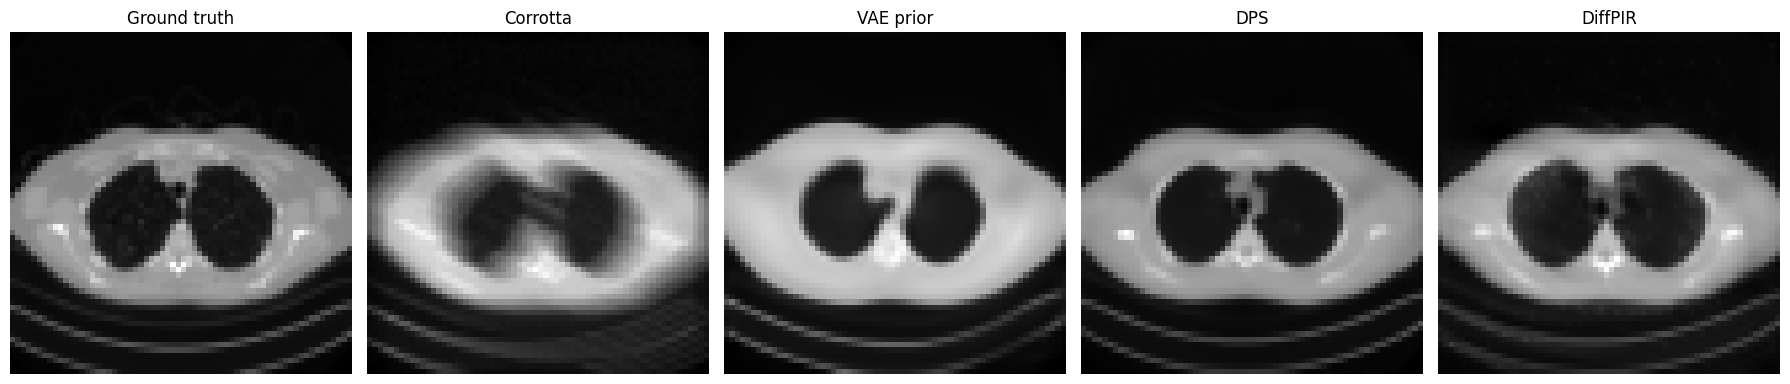

In [28]:
def m(rec):
    a=rec.clamp(0,1).cpu().squeeze().numpy(); b=x_true.clamp(0,1).cpu().squeeze().numpy()
    mse=float(((a-b)**2).mean())
    return mse, sk_psnr(b,a,data_range=1.0), sk_ssim(b,a,data_range=1.0)

for name,rec in [('Corrotta',y_delta),('VAE prior',x_vae),('DPS',x_dps),('DiffPIR',x_diffpir)]:
    mse,ps,ss=m(rec); print(f'{name:<10} | MSE={mse:.6f} | PSNR={ps:.2f} dB | SSIM={ss:.4f}')

imgs=[x_true,y_delta,x_vae,x_dps,x_diffpir]; titles=['Ground truth','Corrotta','VAE prior','DPS','DiffPIR']
plt.figure(figsize=(18,4))
for i,(im,t) in enumerate(zip(imgs,titles)):
    plt.subplot(1,5,i+1); plt.imshow(im.cpu().squeeze().clamp(0,1),cmap='gray'); plt.title(t); plt.axis('off')
plt.tight_layout(); plt.show()

1. Which generative prior worked best, and why?

In our experiment DiffPIR gave the best reconstruction (PSNR 27.40 dB, SSIM 0.810), the only method that clearly improved on the corrupted image. The reason is structural: DiffPIR alternates an explicit denoising step (the pretrained diffusion prior pushes the estimate toward a plausible clean image) with an explicit data-consistency step that corrects the estimate toward the measurement using the known operator K and its adjoint Kᵀ. This combination keeps the result both realistic and faithful to the data. The VAE prior and DPS scored below the corrupted image, which mostly reflects their stronger sensitivity to tuning rather than a fundamental weakness.

2. Practical difference between DPS and DiffPIR.

Both use the same pretrained diffusion denoiser as prior, but they enforce data consistency differently. DPS adds, at each step, the gradient of the data-fidelity term ‖K·x̂₀ − y‖² to guide the sampling: it is a soft, gradient-based nudge whose strength depends on a guidance parameter, which makes it powerful but sensitive, too small and it never locks onto the data, too large and it becomes unstable. DiffPIR instead applies a more direct correction/projection step using K and Kᵀ after each denoising step, which is numerically more stable and, in our case, gave a better and more reliable result with less tuning.

3. Limitation of the VAE latent prior (latent dim 64).

The VAE compresses a 64×64 image into a 64-dimensional latent vector, so the decoder can only represent images that live in that low-dimensional learned manifold. Fine details and thin structures that don't fit this compact code cannot be reconstructed, so the output tends to look plausible but smoothed and generic. This is an intrinsic capacity limit: even with perfect optimisation of z, the reconstruction cannot be sharper than what a 64-dim latent can express. It explains why the VAE prior was the weakest of the three.

4. Why generate the corruption through a known operator K instead of a generic image-to-image task?

Because the whole point of an inverse problem is that we know the physics of the degradation: y = K x + e. Encoding this knowledge through K lets the methods enforce data consistency, they can check whether a candidate reconstruction, once re-degraded by K, actually reproduces the measurement. A generic image-to-image model has no access to K, so it can only learn a statistical mapping and may "hallucinate" content that looks right but is inconsistent with the actual measurement. Using K makes the reconstruction grounded in the measurement model and far more trustworthy.

5. Why is a visually pleasing reconstruction not automatically reliable?

Generative priors are very good at producing images that look clean and realistic, but "realistic" is not the same as "correct". A diffusion or VAE prior can fill in plausible details that were never in the true image especially under heavy noise or blur, so a sharp, convincing result may actually contain invented structures. In an inverse problem we must always weigh visual quality against data consistency (does it match y through K?), the noise model, and the risk of distribution shift. This is why we report quantitative metrics (PSNR, SSIM) and check agreement with the measurement, rather than trusting the appearance alone, which matters especially in medical imaging, where a hallucinated detail could be misleading.